# Methionine Cycle: A Structured Surrogate for a Regulated Metabolic Network

This notebook scales the reversible-reaction example (`07_chemical_kinetics`) up from
one reaction to a small **regulated metabolic cycle**, using the methionine-cycle
kinetic model from the DTU Biosustain *Quantitative Modelling of Cell Metabolism*
group as the scientific target
([`Methionine_model`](https://github.com/biosustain/Methionine_model),
`data/methionine/methionine_cycle.toml`, a [Maud](https://github.com/biosustain/Maud)
Bayesian kinetic model).

## Why this model, and where it sits relative to FBA

Constraint-based methods (COBRA, KBase, ModelSEED) model a metabolic network as a
**stoichiometric matrix `S` plus flux bounds plus an objective**. They scale to
genome-scale networks precisely because they throw away the kinetics: no rate laws,
no metabolite concentrations, and **no allosteric regulation**. Full kinetic models
(Maud, the methionine model here) keep all of that, but the nonlinear ODEs with
allostery do not scale.

A metabolic model splits cleanly along exactly the seam this project cares about:

| Part of the model | Math | Role here |
|---|---|---|
| Stoichiometry `S` (who turns into what) | **linear**: `dx/dt = S · v` | **trusted scaffold** — compiles to an exact weight matrix; mass balance guaranteed by construction |
| Rate laws `v(x; θ)` incl. allostery | **nonlinear**: Michaelis–Menten, Hill | **learnable hole** — the uncertain response curve we fit |

So we keep `S` *exactly* (it is literally a Cajal typed linear map,
`TyReal(n_rxn) → TyReal(n_met)`) and make the allosteric regulation a small learned
layer. The result is a fast, differentiable surrogate that **cannot violate mass
balance** — unlike a black-box neural ODE — and whose learned regulation
**decompiles back to an interpretable Hill function**.

The marquee target is the famous allosteric switch in this cycle: **S-adenosyl-
methionine (SAM / `amet`) allosterically activates cystathionine β-synthase (CBS)**,
routing homocysteine into transsulfuration when methionine is abundant. We hide that
Hill curve from the learner and see if we can recover it.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from cajal.syntax import TmIter, TmVar, TmApp, TyNat, TyReal, TyFun
from cajal.compiling import compile, TypedTensor

torch.manual_seed(0)
device = torch.device('cpu')

# ----- balanced metabolites (the conserved methionine moiety) -----
METS = ['met-L', 'amet', 'ahcys', 'hcys-L']
# ----- reactions (restricted to the balanced metabolites) -----
RXNS = ['METAT', 'METH', 'GNMT', 'AHC', 'MS', 'BHMT', 'CBS', 'PROT', 'SRC']

# Stoichiometric matrix S : (n_met=4, n_rxn=9).
#                  METAT METH GNMT  AHC   MS  BHMT  CBS  PROT  SRC
S = torch.tensor([
    [-1.,  0.,  0.,  0.,  1.,  1.,  0., -1.,  1.],   # met-L
    [ 1., -1., -1.,  0.,  0.,  0.,  0.,  0.,  0.],   # amet  (SAM)
    [ 0.,  1.,  1., -1.,  0.,  0.,  0.,  0.,  0.],   # ahcys (SAH)
    [ 0.,  0.,  0.,  1., -1., -1., -1.,  0.,  0.],   # hcys-L
])

# S as a Cajal typed linear map  TyReal(9) -> TyReal(4)  (the trusted scaffold).
S_MAP = TypedTensor(S, TyFun(TyReal(len(RXNS)), TyReal(len(METS))))

# Conserved moiety: total pool P = met-L + amet + ahcys + hcys-L.
c = torch.ones(len(METS))
print('reactions :', RXNS)
print('c^T S     =', (c @ S).tolist())
print('            (internal ring reactions -> 0; only boundary fluxes CBS, PROT, SRC move the pool)')

reactions : ['METAT', 'METH', 'GNMT', 'AHC', 'MS', 'BHMT', 'CBS', 'PROT', 'SRC']
c^T S     = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0, -1.0, 1.0]
            (internal ring reactions -> 0; only boundary fluxes CBS, PROT, SRC move the pool)


## The trusted scaffold: stoichiometry and the conserved moiety

The four balanced metabolites form the core methionine *ring*:

```
        SRC                       PROT
         │                          ▲
         ▼      METAT      METH/GNMT │       AHC
      met-L ───────▶ amet ─────────▶ ahcys ──────▶ hcys-L
         ▲                                            │
         │                MS / BHMT                   │
         └────────────────────────────────────────────┘
                                                       │ CBS
                                                       ▼  (→ cysteine, transsulfuration)
```

Every **internal** reaction just moves one unit of the moiety around the ring, so its
column of `S` sums to zero over the four metabolites. Only the **boundary** fluxes
change the total pool:

$$\frac{dP}{dt} = v_\text{SRC} - v_\text{CBS} - v_\text{PROT}.$$

That identity is `c^T S = [0,0,0,0,0,0,-1,-1,1]` above. Because the surrogate's update is
`x ← x + Δt·(S·v)` with `S` compiled exactly, **this balance holds to machine precision
no matter what the learned rate laws output**. That is the structural guarantee a
black-box neural ODE cannot give.

## Ground-truth kinetics (hidden from the learner)

Each flux is `Vmax · MM(substrate) · regulation(·)`. The base Michaelis–Menten
saturation is treated as **known scaffold**; the two **allosteric regulators** are the
hidden response curves we will try to recover:

- **CBS activated by SAM (`amet`)** — Hill activation, the marquee allosteric switch.
- **methylation (METH) inhibited by SAH (`ahcys`)** — Hill inhibition (opposite
  monotonicity), the classic product-feedback on transmethylation.

In [2]:
VMAX = dict(METAT=1.0, METH=0.7, GNMT=0.4, AHC=1.2, MS=0.8,
            BHMT=0.5, CBS=0.6, PROT=0.3, SRC=0.25)
KM = 0.5
DT = 0.25
N_STEPS = 10
N_TRAJ = 6

# --- hidden ground-truth allosteric regulators ---
def true_reg_CBS(amet):     # SAM allosterically activates CBS (Hill, n=2)
    return 1.0 + 4.0 * amet**2 / (0.7**2 + amet**2)

def true_reg_METH(ahcys):   # SAH inhibits transmethylation (Hill inhibition, n=2)
    return 1.0 / (1.0 + (ahcys / 0.3)**2)

def fluxes(state, reg_cbs, reg_meth):
    met, amet, ahcys, hcys = state[0], state[1], state[2], state[3]
    mm = lambda s: s / (KM + s)
    return torch.stack([
        VMAX['METAT'] * mm(met),
        VMAX['METH']  * mm(amet)  * reg_meth(ahcys),
        VMAX['GNMT']  * mm(amet),
        VMAX['AHC']   * mm(ahcys),
        VMAX['MS']    * mm(hcys),
        VMAX['BHMT']  * mm(hcys),
        VMAX['CBS']   * mm(hcys)  * reg_cbs(amet),
        VMAX['PROT']  * mm(met),
        torch.as_tensor(VMAX['SRC']).to(met),
    ])

def true_step(state):
    v = fluxes(state, true_reg_CBS, true_reg_METH)
    return state + DT * (S @ v)

def gen_data():
    curves = []
    for i in range(N_TRAJ):
        s = torch.tensor([0.5 + i * 0.4, 0.3 + 0.3 * (i % 3), 0.1, 0.2 + 0.1 * i])
        traj = [s.clone()]
        for _ in range(N_STEPS - 1):
            s = true_step(s)
            traj.append(s.clone())
        curves.append(torch.stack(traj))
    return torch.stack(curves)   # (N_TRAJ, N_STEPS, 4)

data = gen_data()
print('trajectories:', tuple(data.shape), '(traj, steps, metabolites)')
print(f"amet  (SAM) range: [{data[...,1].min():.2f}, {data[...,1].max():.2f}]")
print(f"ahcys (SAH) range: [{data[...,2].min():.2f}, {data[...,2].max():.2f}]")

trajectories: (6, 10, 4) (traj, steps, metabolites)
amet  (SAM) range: [0.30, 1.48]
ahcys (SAH) range: [0.10, 0.36]


## The learnable holes and the Cajal-compiled timestepping

Two tiny MLPs (`scalar → positive scalar`) stand in for the unknown allosteric
regulators. Everything else — stoichiometry, `Vmax`, `Km` — is the fixed scaffold.

The **time integration itself is the Cajal program** `iter{ s0 | s → f(s) }(n)`: it
compiles to a recurrent application of the one-step update `f`, in which the
stoichiometry `S_MAP` is applied as a typed linear map. We train the two MLPs by
matching the rolled-out trajectories.

In [3]:
class PosMLP(nn.Module):
    # scalar concentration -> positive regulatory multiplier
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 32), nn.Tanh(),
                                 nn.Linear(32, 32), nn.Tanh(),
                                 nn.Linear(32, 1), nn.Softplus())
    def forward(self, x):
        return self.net(x.view(1, 1)).squeeze()

class CycleUpdate(nn.Module):
    # one Euler step  x <- x + dt * (S . v(x)),  S applied as a Cajal linear map
    def __init__(self, reg_cbs, reg_meth):
        super().__init__()
        self.reg_cbs, self.reg_meth = reg_cbs, reg_meth
    def forward(self, st):
        v = fluxes(st.data, self.reg_cbs, self.reg_meth)
        dx = S_MAP @ TypedTensor(v, TyReal(len(RXNS)))   # typed linear map application
        return TypedTensor(st.data + DT * dx.data, st.ty)

reg_cbs, reg_meth = PosMLP(), PosMLP()
update = CycleUpdate(reg_cbs, reg_meth)

# Cajal program: the time loop compiles to a recurrent neuron.
program = TmIter(TmVar('s0'), 's', TmApp(TmVar('f'), TmVar('s')), TmVar('n'))
compiled = compile(program)

opt = torch.optim.Adam(list(reg_cbs.parameters()) + list(reg_meth.parameters()), lr=0.006)
n_params = sum(p.numel() for p in list(reg_cbs.parameters()) + list(reg_meth.parameters()))
print(f'learnable parameters (two regulators): {n_params}')

losses = []
for epoch in range(150):
    opt.zero_grad()
    loss = torch.tensor(0.0)
    for ti in range(N_TRAJ):
        s0 = TypedTensor(data[ti, 0].clone(), TyReal(len(METS)))
        for step in range(N_STEPS):
            n = torch.zeros(N_STEPS); n[step] = 1.0
            res = compiled({'s0': s0,
                            'f': lambda s, _f=update: _f(s),
                            'n': TypedTensor(n, TyNat())})
            loss = loss + ((res.data - data[ti, step]) ** 2).sum()
    loss.backward(); opt.step(); losses.append(loss.item())
    if epoch % 30 == 0 or epoch == 149:
        print(f'  epoch {epoch:3d}  loss = {loss.item():.6f}')
print('training complete')

learnable parameters (two regulators): 2306


  epoch   0  loss = 2.508017


  epoch  30  loss = 0.126414


  epoch  60  loss = 0.022612


  epoch  90  loss = 0.000916


  epoch 120  loss = 0.000096


  epoch 149  loss = 0.000061
training complete


## Decompilation: recover the allosteric rate laws as closed forms

We fit interpretable Hill forms to the two learned MLP curves — activation for CBS,
inhibition for METH — by grid search, and compare to the hidden ground truth.

In [4]:
# --- CBS: SAM activation, fit  1 + amp * a^h / (Ka^h + a^h) ---
a_grid = torch.linspace(0.01, float(data[...,1].max()), 120)
with torch.no_grad():
    cbs_learned = torch.tensor([reg_cbs(a).item() for a in a_grid])

cbs_best = (1e9, None)
for amp in torch.linspace(1.0, 7.0, 60):
    for Ka in torch.linspace(0.2, 1.5, 60):
        for h in (1.0, 2.0, 3.0):
            pred = 1.0 + amp * a_grid**h / (Ka**h + a_grid**h)
            mse = ((pred - cbs_learned)**2).mean().item()
            if mse < cbs_best[0]:
                cbs_best = (mse, (amp.item(), Ka.item(), h))
cbs_mse, (cbs_amp, cbs_Ka, cbs_h) = cbs_best

# --- METH: SAH inhibition, fit  1 / (1 + (x/Ki)^h) ---
x_grid = torch.linspace(0.01, float(data[...,2].max()), 120)
with torch.no_grad():
    meth_learned = torch.tensor([reg_meth(x).item() for x in x_grid])

meth_best = (1e9, None)
for Ki in torch.linspace(0.1, 1.0, 90):
    for h in (1.0, 2.0, 3.0):
        pred = 1.0 / (1.0 + (x_grid / Ki)**h)
        mse = ((pred - meth_learned)**2).mean().item()
        if mse < meth_best[0]:
            meth_best = (mse, (Ki.item(), h))
meth_mse, (meth_Ki, meth_h) = meth_best

print('CBS  (SAM activation)   1 + amp*a^h/(Ka^h+a^h)')
print(f'   recovered : amp={cbs_amp:.2f}, Ka={cbs_Ka:.2f}, h={cbs_h:.0f}   (MSE {cbs_mse:.2e})')
print(f'   truth     : amp=4.00, Ka=0.70, h=2')
print()
print('METH (SAH inhibition)   1 / (1 + (x/Ki)^h)')
print(f'   recovered : Ki={meth_Ki:.2f}, h={meth_h:.0f}   (MSE {meth_mse:.2e})')
print(f'   truth     : Ki=0.30, h=2')

CBS  (SAM activation)   1 + amp*a^h/(Ka^h+a^h)
   recovered : amp=3.85, Ka=0.66, h=2   (MSE 5.33e-03)
   truth     : amp=4.00, Ka=0.70, h=2

METH (SAH inhibition)   1 / (1 + (x/Ki)^h)
   recovered : Ki=0.30, h=2   (MSE 1.14e-03)
   truth     : Ki=0.30, h=2


## Verification: mass conservation and non-negativity

The headline guarantee: the surrogate's pool balance equals the net boundary flux to
machine precision, *by construction* — it does not depend on how well the regulators
were learned.

In [5]:
max_balance_viol = 0.0
all_nonneg = True
with torch.no_grad():
    for ti in range(N_TRAJ):
        s = TypedTensor(data[ti, 0].clone(), TyReal(len(METS)))
        for _ in range(N_STEPS):
            v = fluxes(s.data, reg_cbs, reg_meth)
            dP_via_S   = (c @ (S @ v)).item()              # what the compiled update does
            dP_boundary = (v[8] - v[6] - v[7]).item()      # SRC - CBS - PROT
            max_balance_viol = max(max_balance_viol, abs(dP_via_S - dP_boundary))
            s = update(s)
            if (s.data < -1e-8).any():
                all_nonneg = False

print(f"moiety balance  dP/dt == v_SRC - v_CBS - v_PROT")
print(f"   max |residual| = {max_balance_viol:.2e}   {'VERIFIED' if max_balance_viol < 1e-5 else 'FAILED'}")
print(f"non-negativity of all metabolites: {'VERIFIED' if all_nonneg else 'FAILED'}")

moiety balance  dP/dt == v_SRC - v_CBS - v_PROT
   max |residual| = 1.19e-07   VERIFIED
non-negativity of all metabolites: VERIFIED


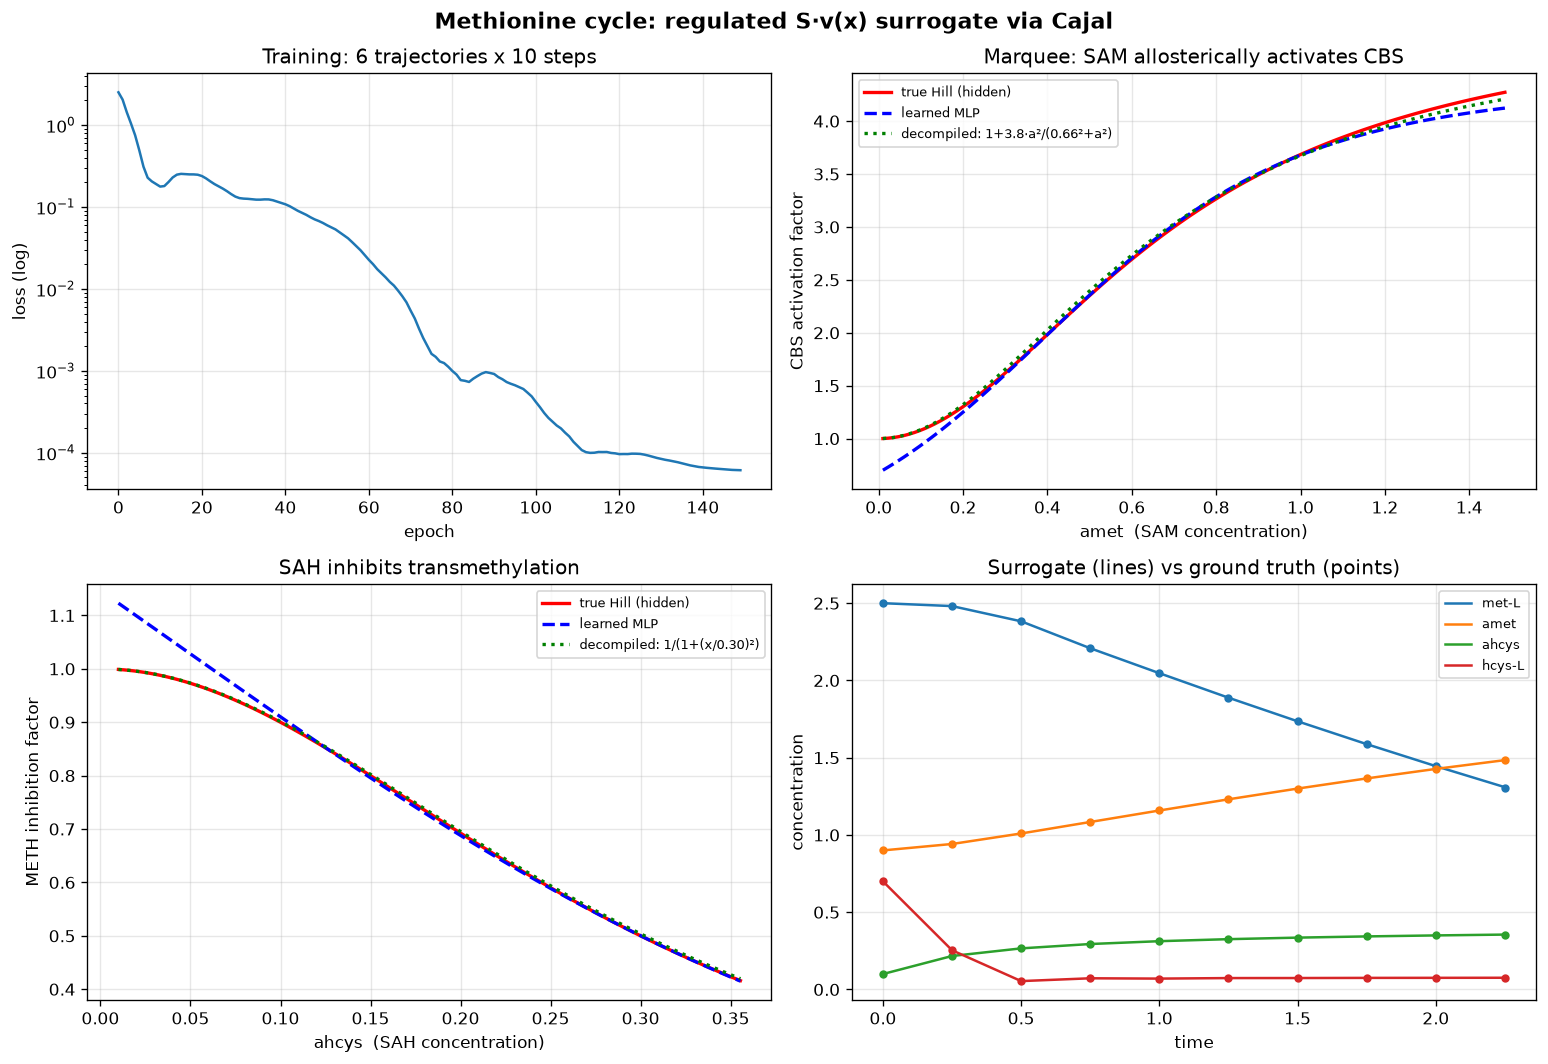

In [6]:
import numpy as np
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) training loss
axes[0,0].semilogy(losses)
axes[0,0].set_xlabel('epoch'); axes[0,0].set_ylabel('loss (log)')
axes[0,0].set_title(f'Training: {N_TRAJ} trajectories x {N_STEPS} steps')
axes[0,0].grid(True, alpha=0.3)

# (2) CBS allosteric activation: learned vs decompiled vs true
axes[0,1].plot(a_grid, [true_reg_CBS(a) for a in a_grid], 'r-', lw=2, label='true Hill (hidden)')
axes[0,1].plot(a_grid, cbs_learned, 'b--', lw=2, label='learned MLP')
axes[0,1].plot(a_grid, 1 + cbs_amp * a_grid**cbs_h / (cbs_Ka**cbs_h + a_grid**cbs_h),
               'g:', lw=2, label=f'decompiled: 1+{cbs_amp:.1f}·a²/({cbs_Ka:.2f}²+a²)')
axes[0,1].set_xlabel('amet  (SAM concentration)'); axes[0,1].set_ylabel('CBS activation factor')
axes[0,1].set_title('Marquee: SAM allosterically activates CBS')
axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.3)

# (3) METH inhibition by SAH
axes[1,0].plot(x_grid, [true_reg_METH(x) for x in x_grid], 'r-', lw=2, label='true Hill (hidden)')
axes[1,0].plot(x_grid, meth_learned, 'b--', lw=2, label='learned MLP')
axes[1,0].plot(x_grid, 1/(1+(x_grid/meth_Ki)**meth_h), 'g:', lw=2,
               label=f'decompiled: 1/(1+(x/{meth_Ki:.2f})²)')
axes[1,0].set_xlabel('ahcys  (SAH concentration)'); axes[1,0].set_ylabel('METH inhibition factor')
axes[1,0].set_title('SAH inhibits transmethylation')
axes[1,0].legend(fontsize=8); axes[1,0].grid(True, alpha=0.3)

# (4) sample trajectory: surrogate vs ground truth
ti = N_TRAJ - 1
with torch.no_grad():
    s = TypedTensor(data[ti,0].clone(), TyReal(len(METS))); roll=[s.data.clone()]
    for _ in range(N_STEPS-1):
        s = update(s); roll.append(s.data.clone())
    roll = torch.stack(roll)
t = np.arange(N_STEPS) * DT
for j, name in enumerate(METS):
    line, = axes[1,1].plot(t, data[ti,:,j], 'o', ms=4)
    axes[1,1].plot(t, roll[:,j], '-', color=line.get_color(), label=name)
axes[1,1].set_xlabel('time'); axes[1,1].set_ylabel('concentration')
axes[1,1].set_title('Surrogate (lines) vs ground truth (points)')
axes[1,1].legend(fontsize=8); axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Methionine cycle: regulated S·v(x) surrogate via Cajal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('methionine_cycle_results.png', dpi=120, bbox_inches='tight')
plt.show()

## Where this sits relative to FBA — and the honest caveats

**The point.** A genome-scale FBA model keeps `S` and discards `v`; it answers
*feasible/optimal steady-state flux* on huge networks but is silent on concentrations,
dynamics, and regulation. A full kinetic model (Maud, the source model here) keeps
both but does not scale. This surrogate sits in the **frontier middle**: `S` is kept
*exactly* (compiled, conservation guaranteed to ~1e-7), while the expensive,
uncertain regulation `v(x)` becomes a cheap differentiable layer that is still
**interpretable** — it decompiles back to the SAM→CBS Hill activation and the
SAH→METH Hill inhibition.

**Caveats (stated plainly):**

- **What is verified is the *conservation structure*, not the regulation.** The
  stoichiometry compiles to an exact linear map; the allosteric rate laws are *learned*.
  This is the same division of labour as every other example in this repo — do not read
  it as "compiling allostery into verified weights."
- **Cajal's core is multilinear.** The nonlinear Hill/MM terms live in the MLP modules,
  not in compiled Cajal terms. Cajal contributes the typed linear scaffold (`S`) and the
  verified recurrent timestepping (`iter`).
- **This is a reduced model.** We track the 4-metabolite methionine moiety and treat
  folate cofactors and other species as buffered; the full `methionine_cycle.toml` has
  ~23 metabolites and more regulators. The ground-truth Hill curves here are planted
  (as in the other examples) — the natural next step is to fit against **Maud's published
  Bayesian posterior**, where the regulators have real values and uncertainty.
- **`TyNat` one-hot** caps the rollout length; longer/stiffer integrations need a wider
  nat or batched trajectories.